In [1]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split

In [2]:
file_path1 = "data/sample_new_1_14.jsonl"  # Update with your actual file path
with open(file_path1, "r") as f:
    data1 = [json.loads(line) for line in f]
# file_path2 = "data/message_trainset_0617_2.jsonl"  # Update with your actual file path
# with open(file_path2, "r") as f:
#     data2 = [json.loads(line) for line in f]

In [3]:
data1[0]

{'context': 'Ty very much.',
 'annotations': [{'start': 0,
   'end': 12,
   'text': 'Ty very much',
   'codes': ['PartnershipPatient', 'Appreciation/Gratitude']}],
 'meta': {'TO_PAT_YN': 'N', 'PAT_ID': 'Z1000037', 'MESSAGE_ID': 68856624}}

In [4]:
len(data1)

517

In [5]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split

# Step 1: Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
raw_data = data1
# Unify the annotation labels
# standard_code = [
#     "InfoGive",
#     "InfoSeek",
#     "PartnershipPatient",
#     "PartnershipProvider",
#     "Socioemotional/Empathy",
#     "SharedDecisionPatient",
#     "SharedDecisionProvider"
# ]
# standard_subcode = [
#     'AcknowledgeError',
#     'Alignment',
#     'Appreciation/Gratitude',
#     'Diagnostics',
#     'Drugs',
#     'Sadness/fear',
#     'SchedulingAppt',
#     'Symptoms',
#     'carecoordination',
#     'connection',
#     'PositiveRemarks/Reward',
#     'maintainCommunication',
#     'salutation',
#     'signoff'
# ]
# standard_code = set(standard_code)
# standard_subcode = set(standard_subcode)



sizes = []
for item in raw_data:
    from_whom = "Provider" if item["meta"]["TO_PAT_YN"] == "Y" else "Patient"
    sentence = item["context"]
    input_text = f"From {from_whom}: {sentence}"
    sizes.append(len(tokenizer.tokenize(input_text)))

(array([143., 152., 104.,  55.,  24.,  19.,  10.,   3.,   5.,   2.]),
 array([  4. ,  26.7,  49.4,  72.1,  94.8, 117.5, 140.2, 162.9, 185.6,
        208.3, 231. ]),
 <BarContainer object of 10 artists>)

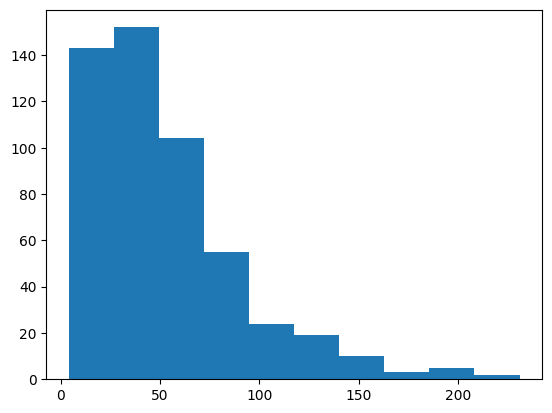

In [6]:
import matplotlib.pyplot as plt

plt.hist(sizes)

In [8]:
def my_clean(txt):
    if "|" in txt:
        txt = txt.split("|")[1]
    txt = txt.strip()
    txt = " ".join(txt.split())
    return txt
def my_clean_label(txt):
    # if txt == "socioemotionalempathy":
    #     txt = "Socioemotional/Empathy"
    # if txt.lower() == "infoseek":
    #     txt =  "InfoSeek"
    # if txt.lower() == "infogive":
    #     txt =  "InfoGive"
    # if txt.lower() == "saddness/fear":
    #     txt =  "Sadness/fear"
    # if txt == "PositiveRemarks":
    #     txt =  "PositiveRemarks/Reward"
    # if txt.lower() == "symptoms":
    #     txt =  "Symptoms"
    # if txt.lower() == "expressconcern,unease" or txt.lower() == "expressconcern/unease":
    #     txt =  "expressconcern/unease"
    # if txt.lower() == "expressconcern,unease":
    #     txt =  "expressconcern/unease"
    # if txt.lower() == "instruction":
    #     txt =  "Instruction"
    # if txt == 'Requests for Opinion' or txt == 'acknowledgePatientExpertiseKnowledge' or txt == 'EncourageQuestions':
    #     return None
    # if txt not in standard_code and txt not in standard_subcode:
    #     return None
    if txt == "SocioEmotionalEmpathy":
        txt = "SocioEmotionalBehaviour"
    return txt
print (f"total number of data {len(raw_data)}")
all_labels = set()
processed = []
count_later = 0
for item in raw_data:
    from_whom = "Provider" if item["meta"]["TO_PAT_YN"] == "Y" else "Patient"
    sentence = my_clean(item["context"])
    if "|" in sentence:
        count_later += 1
        print (sentence)
    input_text = sentence
    label_list = []
    for ann in item.get("annotations"):
        if len(ann['codes']) >= 2:
            code_main = my_clean_label(ann['codes'][0])
            code_sub = my_clean_label(ann['codes'][1])
        elif len(ann['codes']) == 1:
            code_main = my_clean_label(ann['codes'][0])
            code_sub = 'None'
        else:
            continue
        # if code_main == "SharedDecisionPatient" or code_main == "SharedDecisionProvider":
        #     code_sub = "None"
        # if code_main is None or code_sub is None:
        #     continue
        label_list.append(f"{code_main}_{code_sub}")
    if (len(label_list) == 0):
        continue
    all_labels.update(label_list)
    processed.append({"text": input_text, "labels": label_list, "messageID": item["meta"]["MESSAGE_ID"]})
print ("count later is ", count_later)
processed[1]

total number of data 517
count later is  0


{'text': "Dr.Person1 I need my prescription sent to the pharmacy for my flecainide acetate 100 mg tablets twice a day the pharmacist has try requesting it no success and I don't have any pills. Person2",
 'labels': ['PartnershipPatient_activeParticipation/involvement',
  'SDOH_HealthCareAccessAndQuality',
  'PartnershipPatient_Clinical care',
  'PartnershipPatient_Clinical care',
  'CareCoordinationPatient_None',
  'SDOH_NeighborhoodAndBuiltEnvironment'],
 'messageID': 75988585}

In [9]:


# Step 3: Label Mapping
all_labels = sorted(list(all_labels))
label2id = {label: idx for idx, label in enumerate(all_labels)}
id2label = {idx: label for label, idx in label2id.items()}

# Step 4: Convert labels to binary matrix
def get_label_vector(label_list):
    vec = [0] * len(label2id)
    for label in label_list:
        vec[label2id[label]] = 1
    return vec

X = np.array([f"{entry["text"]}|{entry["messageID"]}" for entry in processed]).reshape(-1, 1)
Y = np.array([get_label_vector(entry["labels"]) for entry in processed])
#Z = np.array([get_label_vector(entry["messageID"]) for entry in processed])

# Step 5: Stratified Split
X_train, Y_train, X_test, Y_test = iterative_train_test_split(X, Y, test_size=0.2)

# Step 6: Reconstruct HF dataset structure
train_data = [{"text": x[0].split("|")[0], "labels": [all_labels[i] for i, v in enumerate(y) if v == 1], "messageID": x[0].split("|")[1]} for x, y in zip(X_train, Y_train)]
test_data  = [{"text": x[0].split("|")[0], "labels": [all_labels[i] for i, v in enumerate(y) if v == 1], "messageID": x[0].split("|")[1]} for x, y in zip(X_test, Y_test)]

In [10]:
from collections import Counter

def count_labels(dataset):
    counter = Counter()
    for sample in dataset:
        counter.update(sample["labels"])
    return counter

train_counts = count_labels(train_data)
test_counts = count_labels(test_data)

# Display counts side-by-side
print("Label\t Train\t Test")
for label in all_labels:
    print(f"{label}\t | {train_counts[label]}\t | {test_counts[label]}")

Label	 Train	 Test
CareCoordinationPatient_None	 | 57	 | 17
CareCoordinationProvider_None	 | 78	 | 20
PartnershipPatient_Appreciation/Gratitude	 | 48	 | 12
PartnershipPatient_Clinical care	 | 145	 | 36
PartnershipPatient_activeParticipation/involvement	 | 150	 | 37
PartnershipPatient_alignment	 | 19	 | 6
PartnershipPatient_build trust	 | 9	 | 2
PartnershipPatient_connection	 | 23	 | 7
PartnershipPatient_expressOpinions	 | 70	 | 14
PartnershipPatient_salutation	 | 81	 | 21
PartnershipPatient_signoff	 | 78	 | 20
PartnershipPatient_statePreferences	 | 23	 | 3
PartnershipProvider_Appreciation/Gratitude	 | 11	 | 1
PartnershipProvider_Clinical Care	 | 118	 | 31
PartnershipProvider_alignment	 | 28	 | 7
PartnershipProvider_build trust	 | 5	 | 2
PartnershipProvider_checkingUnderstanding/clarification	 | 36	 | 9
PartnershipProvider_connection	 | 25	 | 7
PartnershipProvider_inviteCollabration	 | 58	 | 15
PartnershipProvider_maintainCommunication	 | 39	 | 13
PartnershipProvider_requestsForOpinion	

In [11]:
import json

with open("data/stratified_train_data_original.json", "w") as f:
    json.dump(train_data, f, indent=4)

with open("data/stratified_test_data_original.json", "w") as f:
    json.dump(test_data, f, indent=4)